In [1]:
%load_ext autoreload

In [2]:
%reload_ext autoreload

In [3]:
%autoreload 2

In [4]:
import sys
import os
from pathlib import Path

In [5]:
BASE_PATH = Path(os.path.abspath('')).parent.parent.parent
sys.path.append(str(BASE_PATH))

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import datetime
import numpy as np

import matplotlib.pyplot as plt
import scienceplots

%matplotlib inline

# plt.style.use(['science','ieee'])
# plt.style.use(['science','nature'])

In [53]:
from binance import enums

In [59]:
from binance.client import Client
import requests

# Spot client (você pode manter se quiser consultar informações Spot também)
spot_client = Client()

# Endpoint público da Binance Futures (não requer autenticação)
futures_exchange_info_url = "https://fapi.binance.com/fapi/v1/exchangeInfo"

# Request direto (alternativamente: use `aiohttp` ou `httpx` para paralelismo)
resp = requests.get(futures_exchange_info_url)
futures_info = resp.json()

# Filtrar os pares de futuros com margem em USDT que estão ativos
futures_symbols = [
    s["symbol"] for s in futures_info["symbols"]
    if s["contractType"] == "PERPETUAL"
    and s["quoteAsset"] == "USDT"
    and s["status"] == "TRADING"
]

print(f"Total de contratos futuros USDT ativos: {len(futures_symbols)}")
# Exemplo: ['BTCUSDT', 'ETHUSDT', ...]

Total de contratos futuros USDT ativos: 445


In [60]:
futures_symbols

['BTCUSDT',
 'ETHUSDT',
 'BCHUSDT',
 'XRPUSDT',
 'LTCUSDT',
 'TRXUSDT',
 'ETCUSDT',
 'LINKUSDT',
 'XLMUSDT',
 'ADAUSDT',
 'XMRUSDT',
 'DASHUSDT',
 'ZECUSDT',
 'XTZUSDT',
 'BNBUSDT',
 'ATOMUSDT',
 'ONTUSDT',
 'IOTAUSDT',
 'BATUSDT',
 'VETUSDT',
 'NEOUSDT',
 'QTUMUSDT',
 'IOSTUSDT',
 'THETAUSDT',
 'ALGOUSDT',
 'ZILUSDT',
 'KNCUSDT',
 'ZRXUSDT',
 'COMPUSDT',
 'DOGEUSDT',
 'SXPUSDT',
 'KAVAUSDT',
 'BANDUSDT',
 'RLCUSDT',
 'MKRUSDT',
 'SNXUSDT',
 'DOTUSDT',
 'DEFIUSDT',
 'YFIUSDT',
 'CRVUSDT',
 'TRBUSDT',
 'RUNEUSDT',
 'SUSHIUSDT',
 'EGLDUSDT',
 'SOLUSDT',
 'ICXUSDT',
 'STORJUSDT',
 'UNIUSDT',
 'AVAXUSDT',
 'ENJUSDT',
 'FLMUSDT',
 'KSMUSDT',
 'NEARUSDT',
 'AAVEUSDT',
 'FILUSDT',
 'RSRUSDT',
 'LRCUSDT',
 'BELUSDT',
 'AXSUSDT',
 'ALPHAUSDT',
 'ZENUSDT',
 'SKLUSDT',
 'GRTUSDT',
 '1INCHUSDT',
 'CHZUSDT',
 'SANDUSDT',
 'ANKRUSDT',
 'RVNUSDT',
 'SFPUSDT',
 'COTIUSDT',
 'CHRUSDT',
 'MANAUSDT',
 'ALICEUSDT',
 'HBARUSDT',
 'ONEUSDT',
 'DENTUSDT',
 'CELRUSDT',
 'HOTUSDT',
 'MTLUSDT',
 'OGNUSDT',
 'NK

In [55]:
info = client.get_exchange_info()
symbols = [s["symbol"] for s in info["symbols"] if s["symbol"].endswith("USDT") and s["status"] == "TRADING" and s["isMarginTradingAllowed"] ==True]

In [58]:
info["symbols"]

[{'symbol': 'ETHBTC',
  'status': 'TRADING',
  'baseAsset': 'ETH',
  'baseAssetPrecision': 8,
  'quoteAsset': 'BTC',
  'quotePrecision': 8,
  'quoteAssetPrecision': 8,
  'baseCommissionPrecision': 8,
  'quoteCommissionPrecision': 8,
  'orderTypes': ['LIMIT',
   'LIMIT_MAKER',
   'MARKET',
   'STOP_LOSS',
   'STOP_LOSS_LIMIT',
   'TAKE_PROFIT',
   'TAKE_PROFIT_LIMIT'],
  'icebergAllowed': True,
  'ocoAllowed': True,
  'otoAllowed': True,
  'quoteOrderQtyMarketAllowed': True,
  'allowTrailingStop': True,
  'cancelReplaceAllowed': True,
  'amendAllowed': True,
  'isSpotTradingAllowed': True,
  'isMarginTradingAllowed': True,
  'filters': [{'filterType': 'PRICE_FILTER',
    'minPrice': '0.00001000',
    'maxPrice': '922327.00000000',
    'tickSize': '0.00001000'},
   {'filterType': 'LOT_SIZE',
    'minQty': '0.00010000',
    'maxQty': '100000.00000000',
    'stepSize': '0.00010000'},
   {'filterType': 'ICEBERG_PARTS', 'limit': 10},
   {'filterType': 'MARKET_LOT_SIZE',
    'minQty': '0.0000

In [57]:
len(symbols)

397

In [ ]:
client.get_historical_klines(enums.HistoricalKlinesType.FUTURES)

In [37]:
from binance.client import Client
import pandas as pd
from datetime import datetime
from tqdm import tqdm

# Initialize Binance Client (Public API - No Key Required)
client = Client()

# Define start and end dates
start_date = "2025-01-01"
end_date = datetime.today().strftime("%Y-%m-%d")  # Dynamic end date

# Get all tradeable Spot crypto pairs (Only USDT pairs)
info = client.get_exchange_info()
symbols = [s["symbol"] for s in info["symbols"] if s["symbol"].endswith("USDT") and s["status"] == "TRADING" and s["isMarginTradingAllowed"] ==True]

# Dictionary to store data
crypto_data = {}

# Fetch historical closing prices for each symbol
for symbol in tqdm(symbols):
    print(f"Fetching {symbol} data...")
    
    klines = client.get_historical_klines(symbol, Client.KLINE_INTERVAL_1HOUR, start_date, end_date)
    
    # Convert to DataFrame
    df = pd.DataFrame(klines, columns=["timestamp", "open", "high", "low", "close", "volume",
                                       "close_time", "quote_asset_volume", "trades", 
                                       "taker_base_vol", "taker_quote_vol", "ignore"])
    
    # Convert timestamp to readable date
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
    
    # Store closing price series in dictionary
    crypto_data[symbol] = df.set_index("timestamp")["close"].astype(float)

# Merge all data into a single DataFrame
crypto_df = pd.DataFrame(crypto_data)

  0%|                                                                                                                                          | 0/402 [00:00<?, ?it/s]

Fetching BTCUSDT data...


  0%|▎                                                                                                                                 | 1/402 [00:02<19:08,  2.87s/it]

Fetching ETHUSDT data...


  0%|▋                                                                                                                                 | 2/402 [00:05<19:10,  2.88s/it]

...

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎| 400/402 [18:31<00:01,  1.42it/s]

Fetching NEWTUSDT data...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋| 401/402 [18:31<00:00,  1.49it/s]

Fetching SAHARAUSDT data...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 402/402 [18:32<00:00,  2.77s/it]


In [38]:
crypto_df.shape

(4489, 402)

In [40]:
portfolio = np.log(crypto_df / crypto_df.shift(1))
portfolio = portfolio.fillna(0.)
portfolio = portfolio.reset_index()
portfolio = portfolio.rename(columns={'timestamp': 'Date'})
portfolio = portfolio.set_index('Date')
portfolio.head()

,BTCUSDT,ETHUSDT,BNBUSDT,NEOUSDT,LTCUSDT,QTUMUSDT,ADAUSDT,XRPUSDT,TUSDUSDT,IOTAUSDT,...,HAEDALUSDT,USD1USDT,HUMAUSDT,AUSDT,SOPHUSDT,RESOLVUSDT,HOMEUSDT,SPKUSDT,NEWTUSDT,SAHARAUSDT
Date,,,,,,,,,,,,,,,,,,,,,
2025-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-01-01 01:00:00,-0.008440,-0.005115,-0.001086,-0.012450,-0.000476,-0.013825,-0.007825,-0.007753,-0.0001,-0.012823,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-01-01 02:00:00,0.005233,0.004790,0.001679,0.003678,-0.000476,0.002317,0.004912,0.005476,0.0000,0.006605,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-01-01 03:00:00,-0.002776,-0.002206,-0.005597,-0.004415,-0.006693,-0.005305,-0.005733,0.000522,0.0000,-0.007652,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-01-01 04:00:00,-0.003032,-0.004199,-0.001149,-0.002954,-0.000480,-0.006002,-0.003644,-0.001995,0.0001,-0.006305,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
# portfolio.USDCUSDT.cumsum().plot()

In [11]:
any(['USDC' in c for c in list(portfolio.columns)])

True

In [12]:
df_portfolio = portfolio.drop(columns=['XTZUSDT'])

In [13]:
# df_portfolio.to_parquet('crypto_market_data_15m.parquet', index=True)

In [14]:
# portfolio = pd.read_csv('crypto_market_data_15m.parquet')
portfolio = df_portfolio.fillna(0.)
portfolio = portfolio.reset_index()
portfolio["Date"] = pd.to_datetime(portfolio["Date"], utc=True)#.dt.date
# portfolio = portfolio[portfolio.Date <= datetime.date(2024, 8, 2)]
portfolio = portfolio.set_index("Date")
portfolio = portfolio.astype(float)
portfolio = portfolio.drop(columns=['BONKUSDT','FLOKIUSDT','OPUSDT', 'UNIUSDT', 'ARBUSDT', 'SHIBUSDT'], axis=1)
portfolio = portfolio[portfolio.mean().sort_values(ascending=False).index[:70]]

In [15]:
inf_idx = np.where(portfolio.values == np.inf)
portfolio.iloc[inf_idx[0]]

,FUNUSDT,VIRTUALUSDT,BANANAS31USDT,SYRUPUSDT,FORMUSDT,TUTUSDT,KAITOUSDT,MKRUSDT,PAXGUSDT,PROMUSDT,...,PENDLEUSDT,MBLUSDT,ZECUSDT,ADAUSDT,BIGTIMEUSDT,REDUSDT,ICXUSDT,LINKUSDT,XNOUSDT,SEIUSDT
Date,,,,,,,,,,,,,,,,,,,,,


In [16]:
portfolio.tail()

,FUNUSDT,VIRTUALUSDT,BANANAS31USDT,SYRUPUSDT,FORMUSDT,TUTUSDT,KAITOUSDT,MKRUSDT,PAXGUSDT,PROMUSDT,...,PENDLEUSDT,MBLUSDT,ZECUSDT,ADAUSDT,BIGTIMEUSDT,REDUSDT,ICXUSDT,LINKUSDT,XNOUSDT,SEIUSDT
Date,,,,,,,,,,,,,,,,,,,,,
2025-07-06 23:00:00+00:00,-0.006749,-0.007214,-0.011114,0.002671,-0.001349,0.000000,-0.003757,-0.007920,-0.000500,0.001446,...,-0.004374,-0.000436,-0.002782,-0.003740,-0.003812,-0.005129,-0.004107,-0.005168,-0.001174,-0.003392
2025-07-06 23:15:00+00:00,0.002280,-0.008752,-0.006144,-0.005707,-0.001570,-0.001614,-0.008329,0.002051,-0.000189,-0.000526,...,-0.004980,-0.006122,-0.004314,-0.004096,-0.006707,-0.003434,0.000000,-0.002965,-0.008260,-0.004920
2025-07-06 23:30:00+00:00,-0.004184,0.003999,-0.000636,0.000894,-0.001060,-0.002426,0.000707,0.003672,-0.001130,0.002363,...,0.003225,-0.000878,-0.000254,0.000855,0.000000,-0.002756,-0.001647,0.002965,0.002367,0.003030
2025-07-06 23:45:00+00:00,0.000305,-0.000322,0.001334,-0.002505,-0.005612,0.003879,0.002633,-0.000052,0.000225,-0.001838,...,0.001463,0.000000,0.000509,0.000854,0.001537,0.002412,0.002470,-0.002223,0.000000,0.000378
2025-07-07 00:00:00+00:00,0.006002,0.000000,-0.007648,-0.004669,0.000110,0.000161,-0.000898,0.003606,-0.000768,-0.000526,...,-0.001463,-0.001318,-0.000763,0.001365,0.000959,0.001376,-0.001646,0.002223,0.001181,0.001511


In [45]:
portfolio = portfolio[
    ['MAGICUSDT',
     'FUNUSDT',
     'FLMUSDT',
     'VOXELUSDT',
     'HFTUSDT',
     'SKLUSDT',
     'BANANAS31USDT',
     'DEXEUSDT',
     'LISTAUSDT',
     '1000CHEEMSUSDT',
     'XNOUSDT',
     'ZECUSDT',
     'COWUSDT',
     'RDNTUSDT',
     'OPUSDT',
     'RPLUSDT',
     'OSMOUSDT',
     'SUSDT',
     'FIOUSDT',
     'NKNUSDT',
     'LQTYUSDT',
     'WIFUSDT',
     'INITUSDT',
     'DATAUSDT',
     'GNSUSDT',
     'CHESSUSDT',
     'PEOPLEUSDT',
     'DOGEUSDT',
     'BCHUSDT',
     'TKOUSDT',
     'XAIUSDT',
     'ZKUSDT',
     'ONEUSDT',
     'KSMUSDT',
     'GMXUSDT',
     'PNUTUSDT',
     'UNIUSDT',
     'FISUSDT',
     'ENJUSDT',
     'CETUSUSDT']
]

In [ ]:
monthly_portfolio = portfolio.resample("M").sum()
monthly_portfolio_std = portfolio.resample("M").std()

returns = pd.DataFrame(np.exp(monthly_portfolio.mean()), columns=["Return"])
risk = pd.DataFrame(np.exp(monthly_portfolio_std.std()), columns=["Risk"])

df_risk_return = returns.merge(risk, left_index=True, right_index=True)

In [ ]:
import numpy as np

# Generate LaTeX table
table = "\\begin{table}[h]\n"
table += "\\centering\n"
table += "\\begin{tabular}{lcc}\n"
table += "\\hline\n"
table += "Stock Symbol & Mean Daily Returns $\\pm$ Daily Risk \\\\\n"
table += "\\hline\n"
for i in range (len(df_risk_return.index)):
    ticker=df_risk_return.index[i]
    x=df_risk_return.loc[ticker, "Risk"]
    y=df_risk_return.loc[ticker, "Return"]
    table += f"{ticker} & ${y:.3f} \\pm {x:.3f}$ \\\\\n"
table += "\\hline\n"
table += "\\end{tabular}\n"
table += "\\caption{Stocks Daily Risks and Returns}\n"
table += "\\end{table}\n"

print(table)


In [ ]:
portfolio.index[-1]

In [ ]:
np.isinf(portfolio).values.sum()

In [ ]:
from colour import Color

blue = Color("red", luminance=0.5)
colors = list(blue.range_to(Color("blue", luminance=0.3), len(portfolio.columns)))

# with plt.style.context(['science', 'ieee', 'no-latex']):
fig, ax = plt.subplots(figsize=(12, 6))
i = 0
for col in portfolio.columns:
    plt.plot(portfolio[col].cumsum(), color=colors[i].rgb, linestyle="-")
    i += 1
#     plt.legend(portfolio.columns, fontsize=4)
plt.xlabel('t', fontsize=12)
plt.ylabel('Cumulative Returns', fontsize=12)
# plt.savefig('01_classes.jpg', dpi=600)

## 1- Investigating the effect of discount (gamma) in d TS

In [ ]:
gamma_vec = np.linspace(0., 1.0, 11)

In [ ]:
gamma_vec

In [ ]:
gamma_hyper_policies = {   
    f"ADTS (min) {i}": {
        "policy_name": "AdaptiveDiscountedThompsonSampling",
        "args": {"n_arms": portfolio.shape[1], "gamma": gamma_vec[i], "f": "min", "w": 100},
        "agents": [],
    }
    for i in range(len(gamma_vec))
}
gamma_hyper_policies.update(
    {   
        f"ADTS (mean) {i}": {
            "policy_name": "AdaptiveDiscountedThompsonSampling",
            "args": {"n_arms": portfolio.shape[1], "gamma": gamma_vec[i], "f": "mean", "w": 100},
            "agents": [],
        }
        for i in range(len(gamma_vec))
    }
)
gamma_hyper_policies.update(
    {   
        f"ADTS (max) {i}": {
            "policy_name": "AdaptiveDiscountedThompsonSampling",
            "args": {"n_arms": portfolio.shape[1], "gamma": gamma_vec[i], "f": "max", "w": 100},
            "agents": [],
        }
        for i in range(len(gamma_vec))
    }
)
gamma_hyper_policies.update(
    {   
        f"FDSWTS (min) {i}": {
            "policy_name": "CavenaghiFDSWTS",
            "args": {"n_arms": portfolio.shape[1], "gamma": gamma_vec[i], "f": "min", "n": 100},
            "agents": [],
        }
        for i in range(len(gamma_vec))
    }
)
gamma_hyper_policies.update(
    {   
        f"FDSWTS (mean) {i}": {
            "policy_name": "CavenaghiFDSWTS",
            "args": {"n_arms": portfolio.shape[1], "gamma": gamma_vec[i], "f": "mean", "n": 100},
            "agents": [],
        }
        for i in range(len(gamma_vec))
    }
)
gamma_hyper_policies.update(
    {   
        f"FDSWTS (max) {i}": {
            "policy_name": "CavenaghiFDSWTS",
            "args": {"n_arms": portfolio.shape[1], "gamma": gamma_vec[i], "f": "max", "n": 100},
            "agents": [],
        }
        for i in range(len(gamma_vec))
    }
)
# gamma_hyper_policies.update(
#     {   
#         f"Classical TS {i}": {
#             "policy_name": "ThompsonSampling",
#             "args": {"n_arms": portfolio.shape[1]},
#             "agents": [],
#         }
#         for i in range(len(gamma_vec))
#     }
# )

In [ ]:
from replay_engines.interface import BacktestInterface, interpolate_colors

gamma_bandit_backtester = BacktestInterface(
    bandit_policies=gamma_hyper_policies,
    n_simulations=20,
    reward_function="WindowedReturnArm",
    reward_function_args=dict(window=60),
    portfolio=portfolio,
)
gamma_bandit_backtester.run(n_threads=3)

In [ ]:
groups = ["ADTS (min)", "ADTS (mean)", "ADTS (max)", "FDSWTS (min)", "FDSWTS (mean)", "FDSWTS (max)"]
markers = ["s", "o", "^", "s", "o", "^"]
linestyles = ["-", "-", "-", "--", "--", "--"]
results_dict = {}
for g in groups:
    results_dict[g] = {
        "gamma_vec": gamma_vec,
        "regret": [],
        "reward": [],
    }
    for k, v in gamma_bandit_backtester.bandit_policies.items():
        if g in k:
            results_dict[g]["regret"].append(v["mean_regret"].sum())
            results_dict[g]["reward"].append(v["mean_reward"].sum())

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the number of colors N
N = 3

# Default Matplotlib colors
matplotlib_orange = np.array(plt.cm.tab10.colors[1])  # index 1 corresponds to default orange
matplotlib_blue = np.array(plt.cm.tab10.colors[0])    # index 0 corresponds to default blue

# Define light versions by increasing the brightness (closer to white)
light_orange = matplotlib_orange + (1 - matplotlib_orange) * 0.4
light_blue = matplotlib_blue + (1 - matplotlib_blue) * 0.3

# Interpolate between the colors
interpolated_orange_colors = [matplotlib_orange + (light_orange - matplotlib_orange) * i / (N - 1) for i in range(N)]
interpolated_blue_colors = [matplotlib_blue + (light_blue - matplotlib_blue) * i / (N - 1) for i in range(N)]

In [ ]:
from replay_engines.interface import interpolate_colors
color_start: str = "#1f77b4"
color_end: str = "#ff7f0e"
colors = interpolate_colors(color_start, color_end, len(results_dict))
colors[-3:] = interpolated_orange_colors

In [ ]:
from colour import Color

# blue = Color("orange")
# colors = list(blue.range_to(Color("blue", luminance=0.3), len(results_dict)))

x_min = 0.79
x_max = 1.01
y_min = 0.
y_max = 1.5

with plt.style.context(['science', 'ieee', 'no-latex']):
    fig, ax = plt.subplots(figsize=(8, 4))
    legend = []
    i = 0
    for policy in results_dict.keys():
        if len(results_dict[policy]['reward']) > 0:
            plt.plot(results_dict[policy]["gamma_vec"], results_dict[policy]["reward"], markers[i], markersize=3, label=policy, color=colors[i], linestyle=linestyles[i])
            i+=1    
    plt.xlabel(r'$\gamma$')
    plt.ylabel('Cumulative Log-Returns')
    plt.legend(loc='upper right', fontsize=7)
    plt.ylim([0, 9.5])
    plt.savefig('04_effect_of_gamma_3.jpg', dpi=600)

## 2- Investigating the window size (w) on sw-d TS

In [ ]:
w_vec = np.linspace(0, 300, 13)
w_vec[0]= 1

In [ ]:
w_vec

In [ ]:
gamma = 0.5

w_polices = {   
    f"ADTS (min) {i}": {
        "policy_name": "AdaptiveDiscountedThompsonSampling",
        "args": {"n_arms": portfolio.shape[1], "gamma": gamma, "f": "min", "w": int(w_vec[i])},
        "agents": [],
    }
    for i in range(len(w_vec))
}
w_polices.update(
    {   
        f"ADTS (mean) {i}": {
            "policy_name": "AdaptiveDiscountedThompsonSampling",
            "args": {"n_arms": portfolio.shape[1], "gamma": gamma, "f": "mean", "w": int(w_vec[i])},
            "agents": [],
        }
        for i in range(len(w_vec))
    }
)
w_polices.update(
    {   
        f"ADTS (max) {i}": {
            "policy_name": "AdaptiveDiscountedThompsonSampling",
            "args": {"n_arms": portfolio.shape[1], "gamma": gamma, "f": "max", "w": int(w_vec[i])},
            "agents": [],
        }
        for i in range(len(w_vec))
    }
)
w_polices.update(
    {   
        f"FDSWTS (min) {i}": {
            "policy_name": "CavenaghiFDSWTS",
            "args": {"n_arms": portfolio.shape[1], "gamma": gamma, "f": "min", "n": int(w_vec[i])},
            "agents": [],
        }
        for i in range(len(w_vec))
    }
)
w_polices.update(
    {   
        f"FDSWTS (mean) {i}": {
            "policy_name": "CavenaghiFDSWTS",
            "args": {"n_arms": portfolio.shape[1], "gamma": gamma, "f": "mean", "n": int(w_vec[i])},
            "agents": [],
        }
        for i in range(len(w_vec))
    }
)
w_polices.update(
    {   
        f"FDSWTS (max) {i}": {
            "policy_name": "CavenaghiFDSWTS",
            "args": {"n_arms": portfolio.shape[1], "gamma": gamma, "f": "max", "n": int(w_vec[i])},
            "agents": [],
        }
        for i in range(len(w_vec))
    }
)

In [ ]:
from replay_engines.interface import BacktestInterface

w_bandit_backtester = BacktestInterface(
    bandit_policies=w_polices,
    n_simulations=20,
    reward_function="WindowedReturnArm",
    reward_function_args=dict(window=60),
    portfolio=portfolio,
)
w_bandit_backtester.run(n_threads=3)

In [ ]:
groups = ["ADTS (min)", "ADTS (mean)", "ADTS (max)", "FDSWTS (min)", "FDSWTS (mean)", "FDSWTS (max)"]
markers = ["s", "o", "^", "s", "o", "^"]
linestyles = ["-", "-", "-", "--", "--", "--"]
results_dict = {}
for g in groups:
    results_dict[g] = {
        "w_vec": w_vec,
        "regret": [],
        "reward": [],
    }
    for k, v in w_bandit_backtester.bandit_policies.items():
        if g in k:
            results_dict[g]["regret"].append(v["mean_regret"].sum())
            results_dict[g]["reward"].append(v["mean_reward"].sum())

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the number of colors N
N = 3

# Default Matplotlib colors
matplotlib_orange = np.array(plt.cm.tab10.colors[1])  # index 1 corresponds to default orange
matplotlib_blue = np.array(plt.cm.tab10.colors[0])    # index 0 corresponds to default blue
matplotlib_green = np.array(plt.cm.tab10.colors[2])    # index 0 corresponds to default green
matplotlib_grey = np.array([0.5, 0.5, 0.5])    # index 0 corresponds to default green

# Define light versions by increasing the brightness (closer to white)
light_orange = matplotlib_orange + (1 - matplotlib_orange) * 0.4
light_blue = matplotlib_blue + (1 - matplotlib_blue) * 0.4
light_green = matplotlib_green + (1 - matplotlib_green) * 0.4
light_grey = matplotlib_grey + (1 - matplotlib_grey) * 0.4

# Interpolate between the colors
interpolated_orange_colors = [matplotlib_orange + (light_orange - matplotlib_orange) * i / (N - 1) for i in range(N)]
interpolated_blue_colors = [matplotlib_blue + (light_blue - matplotlib_blue) * i / (N - 1) for i in range(N)]
interpolated_green_colors = [matplotlib_green + (light_green - matplotlib_green) * i / (N - 1) for i in range(N)]

N=3
interpolated_grey_colors = [matplotlib_grey + (light_grey - matplotlib_grey) * i / (N - 1) for i in range(N)]
colors = interpolated_blue_colors + interpolated_orange_colors

In [ ]:
from colour import Color

blue = Color("orange")
# colors = list(blue.range_to(Color("blue", luminance=0.3), len(results_dict)))

with plt.style.context(['science', 'ieee', 'no-latex']):
    fig, ax = plt.subplots(figsize=(6, 3))
    legend = []
    i = 0
    for policy in results_dict.keys():
        if len(results_dict[policy]['reward']) > 0:
            plt.plot(results_dict[policy]["w_vec"], results_dict[policy]["reward"], markers[i], markersize=2, label=policy, color=colors[i], linestyle=linestyles[i])
            i+=1    
    plt.xlabel('w')
    plt.ylabel('Cumulative Log-Returns')
    plt.legend(loc='upper right', fontsize=7)
    plt.ylim([0, 9.5])
    plt.savefig('04_effect_of_w_3.jpg', dpi=600)

## 3- Investigating the Rewards and Regrets

In [ ]:
policies = {
    "ADTS (min)": {
        "policy_name": "AdaptiveDiscountedThompsonSampling",
        "args": {"n_arms": portfolio.shape[1], "gamma": 0.2, "f": "min", "w": 100},
    },
    # "ADTS (max)": {
    #     "policy_name": "AdaptiveDiscountedThompsonSampling",
    #     "args": {"n_arms": portfolio.shape[1], "gamma": 0.95, "f": "max", "w": 30},
    # },
    "ADTS (mean)": {
        "policy_name": "AdaptiveDiscountedThompsonSampling",
        "args": {"n_arms": portfolio.shape[1], "gamma": 0.2, "f": "mean", "w": 100},
    },
    "F-DSW TS (min)": {
        "policy_name": "CavenaghiFDSWTS",
        "args": {"n_arms": portfolio.shape[1], "gamma": 1.0, "f": "min", "n": 125},
    },
    "F-DSW TS (max)": {
        "policy_name": "CavenaghiFDSWTS",
        "args": {"n_arms": portfolio.shape[1], "gamma": 1.0, "f": "max", "n": 125},
    },
    # "F-DSW TS (mean)": {
    #     "policy_name": "CavenaghiFDSWTS",
    #     "args": {"n_arms": portfolio.shape[1], "gamma": 1.0, "f": "mean", "n": 125},
    # },
    "D TS": {
        "policy_name": "BetaDiscountedThompsonSampling",
        "args": {"n_arms": portfolio.shape[1], "gamma": 0.99},
    },
    "Classical TS": {
        "policy_name": "ThompsonSampling",
        "args": {"n_arms": portfolio.shape[1]},
    },
    "D UCB": {
        "policy_name": "DiscountedUCB1",
        "args": {"n_arms": portfolio.shape[1], "gamma": 0.1},
    },
    "SW UCB": {
        "policy_name": "SlidingWindowUCB1",
        "args": {"n_arms": portfolio.shape[1], "w": 100},
    },
    "UCB1": {
        "policy_name": "UCB1",
        "args": {"n_arms": portfolio.shape[1]},
    },
    # "$\epsilon$-Greedy": {
    #     "policy_name": "EpsilonGreedy",
    #     "args": {"n_arms": portfolio.shape[1], "epsilon": 0.02},
    # },
}

In [ ]:
from replay_engines.interface import BacktestInterface

crypto_bandit_backtester = BacktestInterface(
    bandit_policies=policies,
    n_simulations=50,
    reward_function="WindowedReturnArm",
    reward_function_args=dict(window=60),
    portfolio=portfolio,
)
crypto_bandit_backtester.run()

In [ ]:
from colour import Color
import numpy as np

blue = Color("orange", luminance=0.5)
colors = list(blue.range_to(Color("blue", luminance=0.3), len(crypto_bandit_backtester.bandit_policies)))

In [ ]:
# crypto_bandit_backtester.plot_regrets(
#     save_fig=True,
#     figure_name="02_cumulative_regrets.jpg",
#     # plot_log=True,
#     personalized_colors=[c.rgb for c in colors]
# )

In [23]:
from bandits_lib.replay_engines.interface import interpolate_colors

def plot_rewards(obj,                 
                 save_fig: bool = False,
                 figure_name: str = None,
                 oracle: np.ndarray = None,
                 oracle_name: str = "Oracle",
                 personalized_colors: list = None,
                 color_start: str = "#1f77b4",
                 color_end: str = "#ff7f0e"):

    if save_fig and figure_name is None:
        raise ValueError("Please provide a figure name to save the plot.")
    
    # Default Matplotlib blue and orange
    color_vector_size = len(obj.bandit_policies)
    colors = interpolate_colors(color_start, color_end, color_vector_size)
    if personalized_colors is not None:
        colors = personalized_colors
    
    with plt.style.context(['science', 'ieee', 'no-latex']):
        plt.subplots(figsize=(6, 3))
    
        if oracle is not None:
            plt.plot(obj.portfolio.index, np.exp(np.cumsum(oracle)), color='black', linestyle='-', label=oracle_name)
    
        i = 0
        for policy, output in obj.bandit_policies.items():
            plt.plot(obj.portfolio.index, np.exp(np.cumsum(output['mean_reward'])), color=colors[i], linestyle='-', label=policy)
            i += 1
        plt.legend(loc='upper left', fontsize=7)
        plt.xlabel('t', fontsize=10)
        plt.ylabel('Cumulative Returns', fontsize=10)
        if save_fig:
            plt.savefig(figure_name, dpi=600)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the number of colors N
N = 2

# Default Matplotlib colors
matplotlib_orange = np.array(plt.cm.tab10.colors[1])  # index 1 corresponds to default orange
matplotlib_blue = np.array(plt.cm.tab10.colors[0])    # index 0 corresponds to default blue
matplotlib_green = np.array(plt.cm.tab10.colors[2])    # index 0 corresponds to default green
matplotlib_grey = np.array([0.5, 0.5, 0.5])    # index 0 corresponds to default green

# Define light versions by increasing the brightness (closer to white)
light_orange = matplotlib_orange + (1 - matplotlib_orange) * 0.4
light_blue = matplotlib_blue + (1 - matplotlib_blue) * 0.3
light_green = matplotlib_green + (1 - matplotlib_green) * 0.4
light_grey = matplotlib_grey + (1 - matplotlib_grey) * 0.4

# Interpolate between the colors
interpolated_orange_colors = [matplotlib_orange + (light_orange - matplotlib_orange) * i / (N - 1) for i in range(N)]
interpolated_blue_colors = [matplotlib_blue + (light_blue - matplotlib_blue) * i / (N - 1) for i in range(N)]
interpolated_green_colors = [matplotlib_green + (light_green - matplotlib_green) * i / (N - 1) for i in range(N)]

N=3
interpolated_grey_colors = [matplotlib_grey + (light_grey - matplotlib_grey) * i / (N - 1) for i in range(N)]


interpolated_blue_colors.reverse()
interpolated_green_colors.reverse()

In [ ]:
colors = interpolated_blue_colors + interpolated_orange_colors + interpolated_green_colors + interpolated_grey_colors

In [ ]:
plot_rewards(
    obj=crypto_bandit_backtester,
    # save_fig=True,
    # figure_name="03_rewards_versus_oracle.jpg",
    oracle_name="Cryptos Average",
    oracle=portfolio.mean(axis=1).values,
    personalized_colors=[c for c in colors]
)

In [18]:
def calculate_metrics(log_returns):
    returns = np.exp(log_returns) - 1
    cumulative_returns = np.cumprod(1 + returns) - 1
    daily_returns = np.mean(returns)
    volatility = np.std(returns)
    drawdown = np.min(cumulative_returns - np.maximum.accumulate(cumulative_returns))
    win_rate = np.sum(returns > 0) / len(returns)
    
    # Risk-adjusted ratios
    risk_free_rate = 0.0  # Assuming risk-free rate is zero
    excess_returns = returns - risk_free_rate
    sharpe_ratio = np.mean(excess_returns) / np.std(excess_returns) * np.sqrt(365)
    downside_deviation = np.std(excess_returns[excess_returns < 0])
    sortino_ratio = np.mean(excess_returns) / downside_deviation
    calmar_ratio = np.mean(excess_returns) / drawdown
    
    return {
        "Cumulative Returns": cumulative_returns[-1],
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": drawdown,
#         "Average Daily Returns": daily_returns,
        "Std. Deviation": volatility,
        # "Win Rate": win_rate,
        # "Sortino Ratio": sortino_ratio,
#         "Calmar Ratio": calmar_ratio
    }

In [19]:
def aggregate_metrics(policies: dict):
    portfolio_history = {}
    index = []
    for policy, output in policies.items():
        metrics_dict = calculate_metrics(output["mean_reward"])
        for k, v in metrics_dict.items():
            if k not in portfolio_history.keys():
                portfolio_history[k] = [v]
            else:
                portfolio_history[k].append(v)
        index.append(policy)
    df = pd.DataFrame(portfolio_history, index=index)
    df = df.sort_values("Cumulative Returns", ascending=False)
    return df

In [ ]:
np.exp(5.5)

In [ ]:
policies = crypto_bandit_backtester.bandit_policies.copy()
policies['Crypto Average'] = {
    "mean_reward": portfolio.mean(axis=1)
}

df_metrics = aggregate_metrics(policies)
df_metrics.to_csv('backtest_linear_bandits_crypto.csv')
df_metrics['Cumulative Returns'] = df_metrics['Cumulative Returns']
df_metrics['Maximum Drawdown'] = df_metrics['Maximum Drawdown']
# df_metrics_pivoted = df_metrics.reset_index().pivot_table(values=['Cumulative Returns', 'Sharpe Ratio', 'Maximum Drawdown', 'Std. Deviation'], columns=['index'])

In [ ]:
df_metrics

In [ ]:
df = pd.read_csv("backtest_linear_bandits_crypto.csv")

In [ ]:
df

In [ ]:
df = df.drop(columns=["Volatility"], axis=1)

In [ ]:
df = df.set_index("Unnamed: 0")

In [ ]:
results_list

In [ ]:
import numpy as np

# Generate LaTeX table
table = "\\begin{table}[h]\n"
table += "\\centering\n"
table += "\\begin{tabular}{lcccccc}\n"
table += "\\hline\n"
table += str(" & ".join(list(df_metrics.columns)))+ "\\\n"
table += "\\hline\n"
for i in range(len(df_metrics.index)):
    ticker=df_metrics.index[i]
    results_list = list(df_metrics.loc[ticker, :])
    results_list = [f"${abs(float(r)):.2f}$" if abs(r) >= 1 else f"${abs(float(r)):.3f}$" for r in results_list]
    start_line = f"{ticker} & "
    end_line = "\\\\\n"
    table +=  start_line + " & ".join(results_list) + end_line
table += "\\hline\n"
table += "\\end{tabular}\n"
table += "\\caption{Stocks Daily Risks and Returns}\n"
table += "\\end{table}\n"

print(table)

In [ ]:
crypto_bandit_backtester.bandit_policies['ADTS (mean)']['agents']

## 4- Investigating Bandit Networks

In [49]:
portfolio_size = 5

bandit_net_policies = {
    # f"Two Stage ADTS (mean) | (n={portfolio_size})": {
    #     "network_name": "BanditNetwork",
    #     "final_layer_policy_name": "AdaptiveDiscountedThompsonSampling",
    #     "final_layer_policy_args": {"n_arms": portfolio.shape[1], "gamma": 0.2, "f": "mean", "w": 200},
    #     "policy_name": "AdaptiveDiscountedThompsonSampling",
    #     "args": {"n_arms": portfolio.shape[1], "gamma": 0.2, "f": "mean", "w": 200},
    #     "combinatorial_agents": [],
    #     "agents": [],
    #     "chosen_superarms": []
    # },
    # f"ADTS (mean) + Classical TS | (n={portfolio_size})": {
    #     "network_name": "BanditNetwork",
    #     "final_layer_policy_name": "AdaptiveDiscountedThompsonSampling",
    #     "final_layer_policy_args": {"n_arms": portfolio.shape[1], "gamma": 0.2, "f": "mean", "w": 200},
    #     "policy_name": "ThompsonSampling",
    #     "args": {"n_arms": portfolio.shape[1]},
    #     "combinatorial_agents": [],
    #     "agents": [],
    #     "chosen_superarms": []
    # },
    # f"ADTS (mean) + f-DSW TS | (n={portfolio_size})": {
    #     "network_name": "BanditNetwork",
    #     "final_layer_policy_name": "AdaptiveDiscountedThompsonSampling",
    #     "final_layer_policy_args": {"n_arms": portfolio.shape[1], "gamma": 0.2, "f": "mean", "w": 200},
    #     "policy_name": "CavenaghiFDSWTS",
    #     "args": {"n_arms": portfolio.shape[1], "gamma": 1.0, "f": "min", "n": 125},
    #     "combinatorial_agents": [],
    #     "agents": [],
    #     "chosen_superarms": []
    # },
    f"ADTS (mean) + SW UCB | (n={portfolio_size})": {
        "network_name": "BanditNetwork",
        "final_layer_policy_name": "AdaptiveDiscountedThompsonSampling",
        "final_layer_policy_args": {"n_arms": portfolio.shape[1], "gamma": 0.95, "f": "mean", "w": 200},
        "policy_name": "AdaptiveDiscountedThompsonSampling",
        "args": {"n_arms": portfolio.shape[1], "gamma": 0.95, "f": "mean", "w": 200},
        "combinatorial_agents": [],
        "agents": [],
        "chosen_superarms": []
    },
}

In [50]:
from bandits_lib.replay_engines.interface import BanditNetworkBacktestInterface

bandit_backtester = BanditNetworkBacktestInterface(
    bandit_policies=bandit_net_policies,
    portfolio_size=portfolio_size,
    n_simulations=5,
    reward_function="WindowedReturnArm",
    reward_function_args=dict(window=30),
    portfolio=portfolio,
)
bandit_backtester.run()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:11<00:00,  2.23s/it]


In [51]:
# blue = Color("orange", luminance=0.5)
# colors = list(blue.range_to(Color("blue", luminance=0.3), len(bandit_backtester.bandit_policies)))

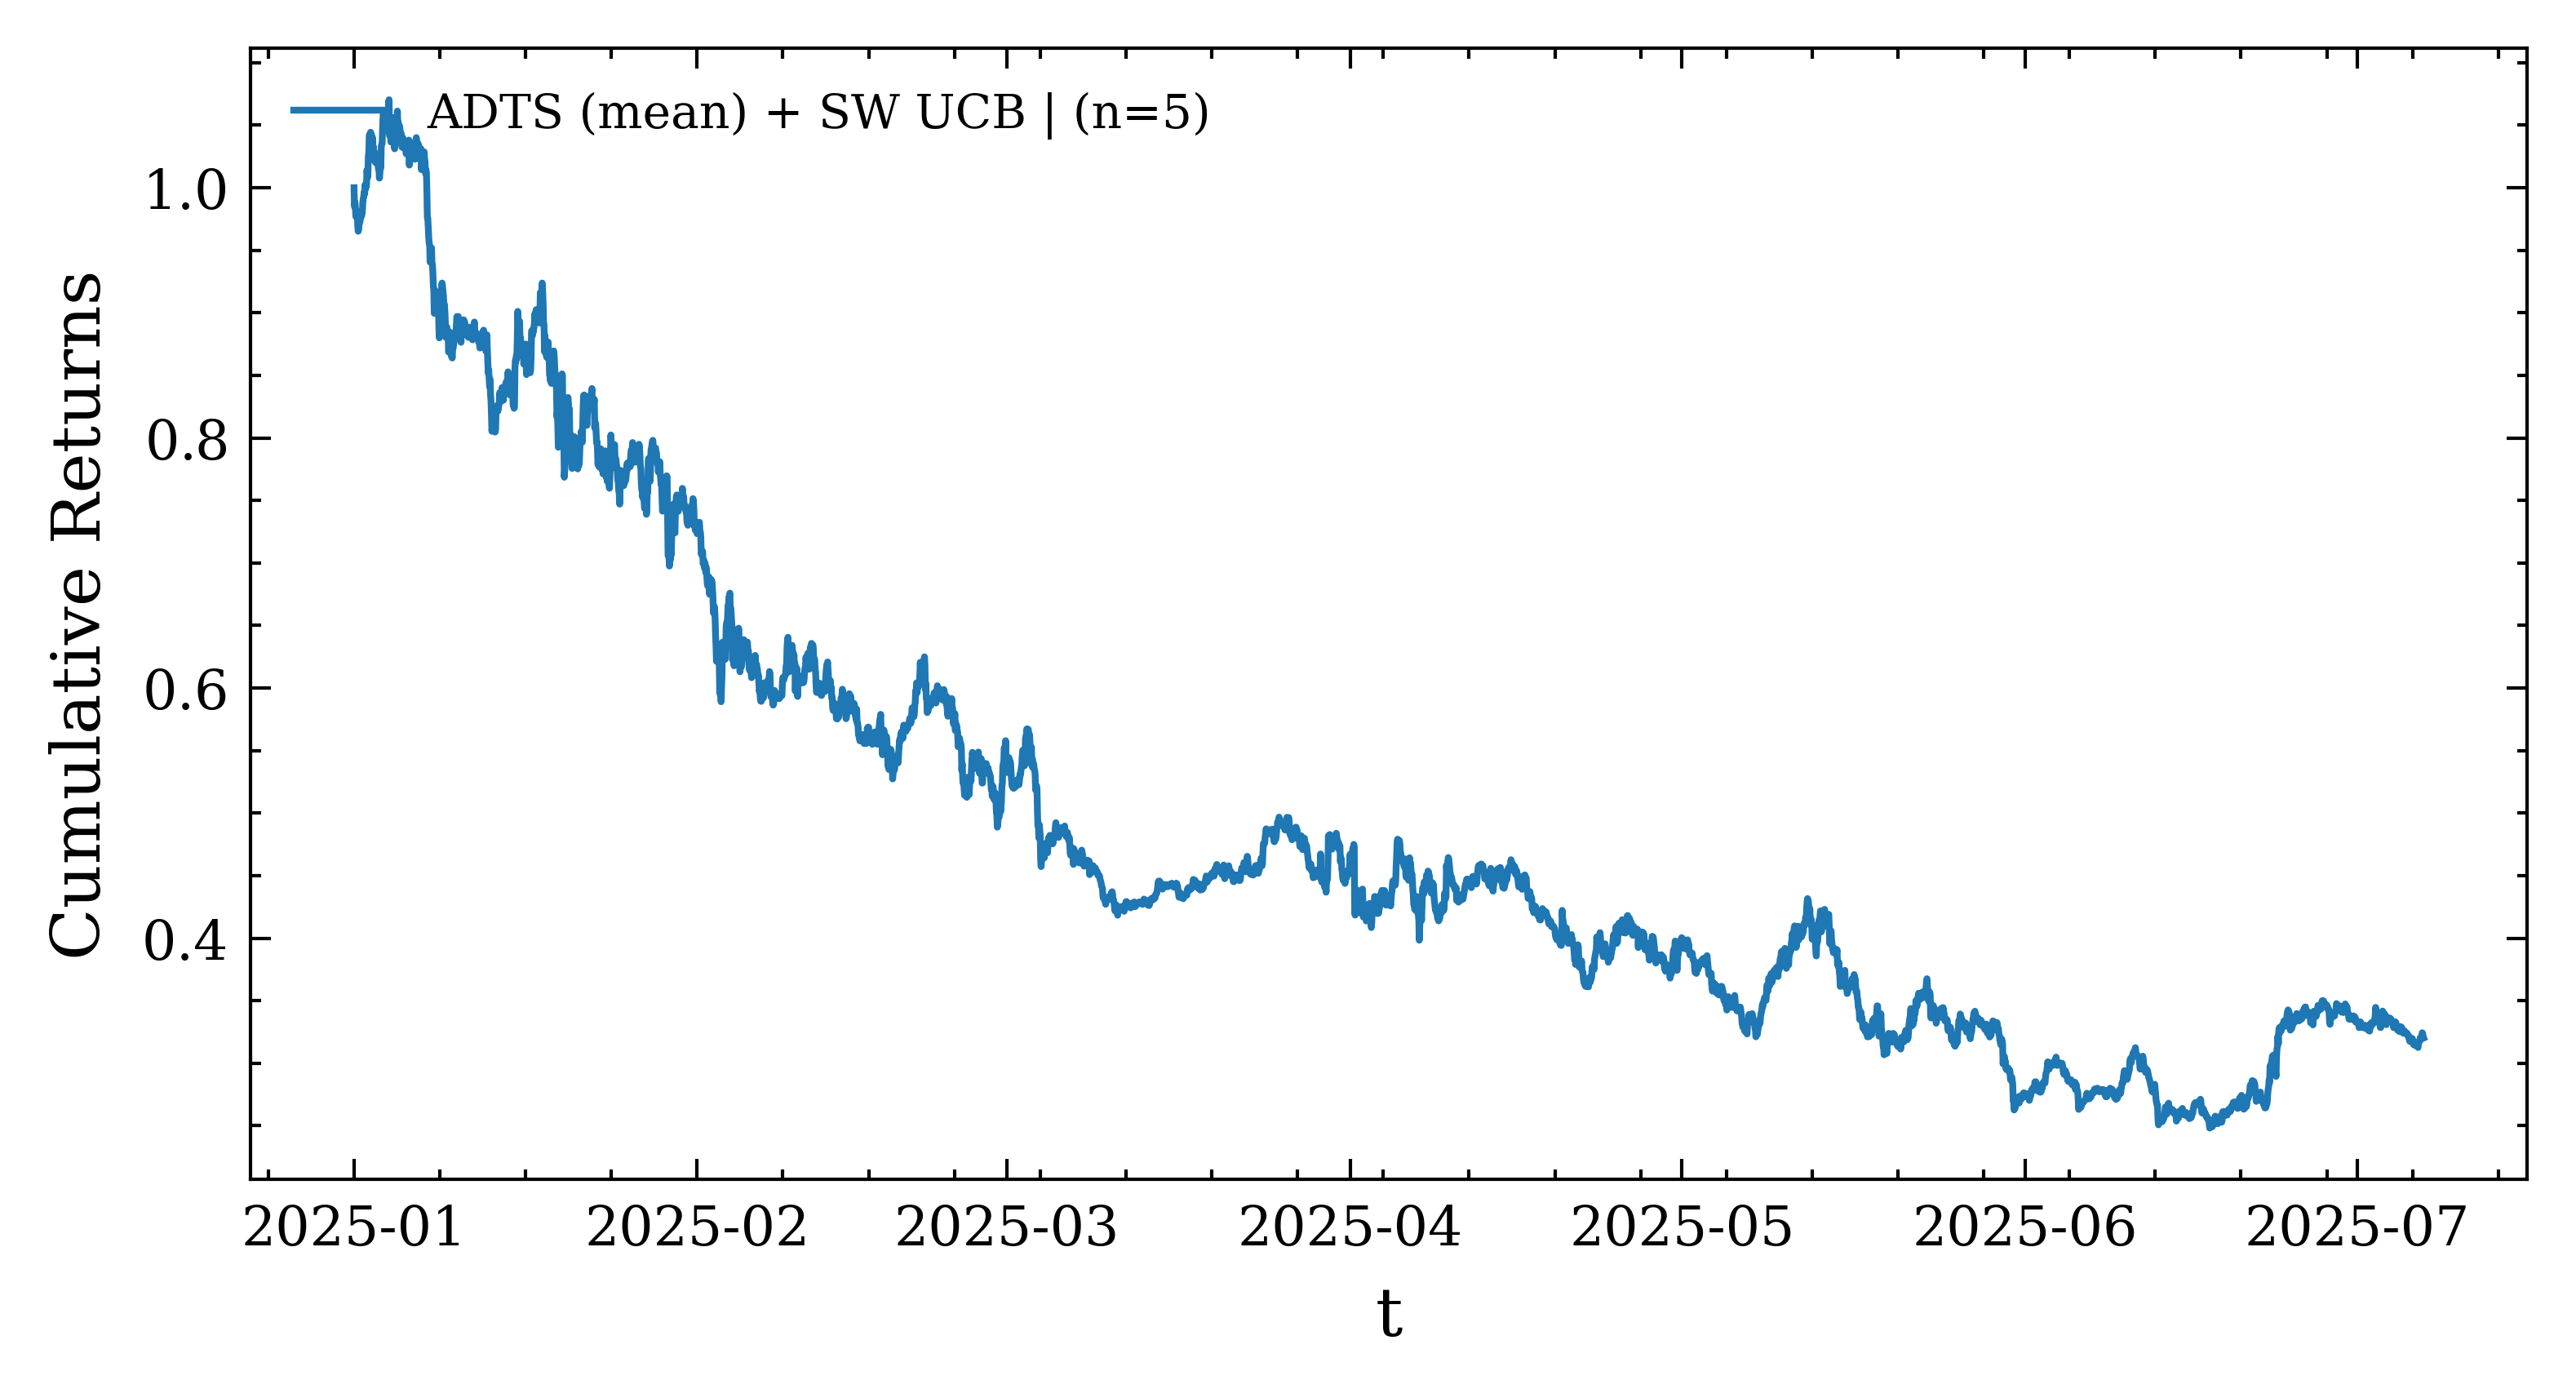

In [52]:
plot_rewards(
    bandit_backtester,
    # save_fig=True,
    # figure_name="03_rewards_versus_oracle_portfolio.jpg",
    # oracle=df_merge['CMC 200'].values,
    # oracle_name='CMC 200 Index',
    # personalized_colors=[c.rgb for c in colors]
)
# ax = plt.gca()
# ax.legend(['a'])
# plt.plot(data[['^CMC200']].cumsum())
# plt.show()

In [ ]:
from bandits_lib.portfolio.classical import MarkovitzPortfolio, EqualWeightsPortfolio, RiskParityPortfolio, CAPMPortfolio
from pandas import DataFrame


def calculate_classical_portfolios(portfolio: DataFrame, adjust_frequency: int = 30) -> DataFrame:
    """
    This function calculates the equal weights, risk parity, Markowitz, and Black-Litterman portfolios.
    """
    equal_weights = EqualWeightsPortfolio(portfolio_log_returns=portfolio, adjust_frequency=adjust_frequency).run_backtest()
    risk_parity = RiskParityPortfolio(portfolio_log_returns=portfolio, adjust_frequency=adjust_frequency).run_backtest()
    markowitz = MarkovitzPortfolio(portfolio_log_returns=portfolio, adjust_frequency=adjust_frequency).run_backtest()
    capm = CAPMPortfolio(portfolio_log_returns=portfolio, adjust_frequency=adjust_frequency).run_backtest()
    return pd.DataFrame({
        "Equal Weights": equal_weights,
        "Risk Parity": risk_parity,
        "Markowitz": markowitz,
        "CAPM": capm,
    })

In [ ]:
portfolio.tail()

In [ ]:
df_classical = calculate_classical_portfolios(portfolio=portfolio)
# df_classical = df_classical.drop(columns=["Unnamed: 0"], axis=1)

In [ ]:
df_classical

In [ ]:
classical_policies = {}

# df_classical = calculate_classical_portfolios(portfolio=portfolio)
for col in df_classical.columns:
    classical_policies[col] = {
        "mean_reward": df_classical[col].fillna(0.).values
    }
# classical_policies['CMC 200'] = {'mean_reward': df_merge['CMC 200'].values}

In [ ]:
unified_policies = bandit_backtester.bandit_policies.copy()
unified_policies.update(classical_policies)

In [ ]:
df_metrics = aggregate_metrics(unified_policies)
# df_metrics.to_csv('backtest_bandit_networks_crypto.csv')
df_metrics

In [ ]:
import numpy as np

# Generate LaTeX table
table = "\\begin{table}[h]\n"
table += "\\centering\n"
table += "\\begin{tabular}{lcccccc}\n"
table += "\\hline\n"
table += str(" & ".join(list(df_metrics.columns)))+ "\\\n"
table += "\\hline\n"
for i in range(len(df_metrics.index)):
    ticker=df_metrics.index[i]
    results_list = list(df_metrics.loc[ticker, :])
    results_list = [f"${abs(float(r)):.2f}$" if abs(r) >= 1 else f"${abs(float(r)):.3f}$" for r in results_list]
    start_line = f"{ticker} & "
    end_line = "\\\\\n"
    table +=  start_line + " & ".join(results_list) + end_line
table += "\\hline\n"
table += "\\end{tabular}\n"
table += "\\caption{Stocks Daily Risks and Returns}\n"
table += "\\end{table}\n"

print(table)

In [ ]:
bandit_arms = bandit_backtester.bandit_policies['ADTS (mean) + SW UCB | (n=10)']['chosen_superarms'][1]['bandit_arms']
weights = bandit_backtester.bandit_policies['ADTS (mean) + SW UCB | (n=10)']['chosen_superarms'][1]['weights']
print(bandit_arms[-1], weights[-1])

In [ ]:
weights[-1].sum()

In [ ]:
plt.plot(portfolio.OMUSDT.cumsum())

In [ ]:
columns = list(portfolio.columns)
{columns[i]: weights[-1][i] for i in range(len(bandit_arms[-1]))}

In [ ]:
plt.figure(figsize=(12, 4))

returns_matrix = portfolio.values
portfolio_returns = np.zeros(len(returns_matrix))

for i in range(len(returns_matrix)):
    portfolio_returns[i] = np.dot(weights[i], returns_matrix[i, bandit_arms[i]])

plt.plot(np.cumsum(portfolio_returns))
plt.plot(np.cumsum(bandit_backtester.bandit_policies['ADTS (mean) + SW UCB | (n=15)']['mean_reward']))